In [2]:
from pathlib import Path
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [3]:
path = Path.cwd()
data_path = path / "Data" / "mental_heath_unbanlanced.csv"
df = pd.read_csv(data_path)
df.head()

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


## Data Exploration

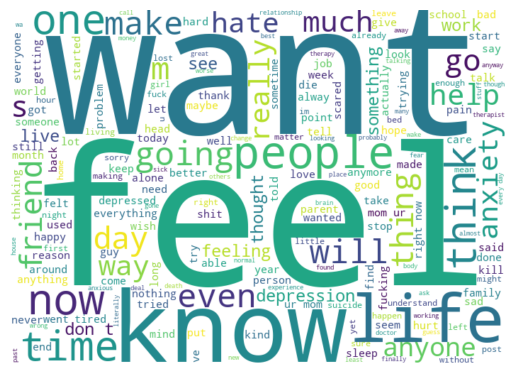

In [4]:
# Wordcloud
text = df['text'].str.cat() # Make the text into one large paragraph
wordcloud = WordCloud(width = 700, height = 500, background_color = 'white').generate(text) # Has built in filter for stop words

# Plot
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maxmar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

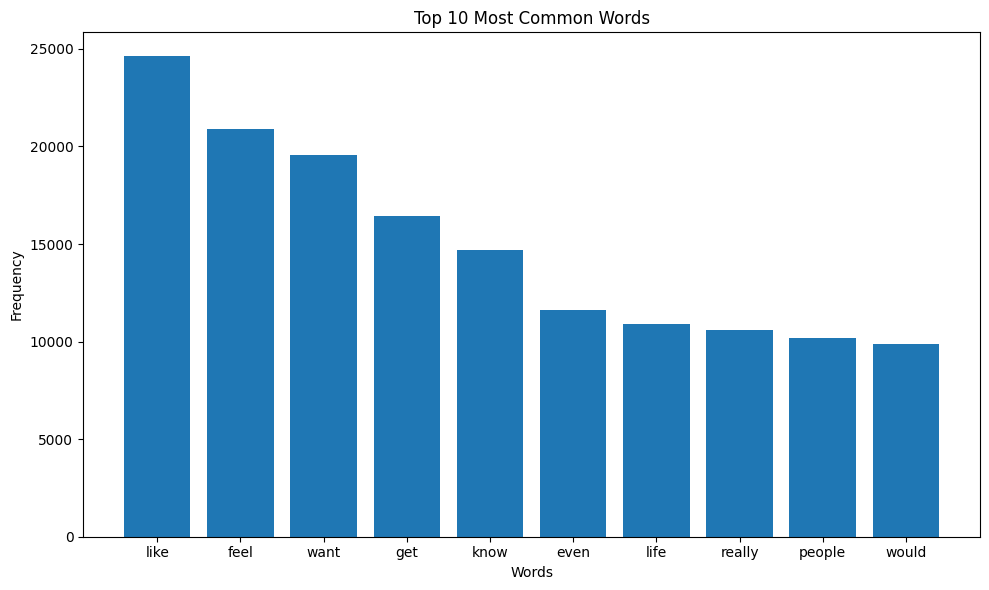

In [6]:
from collections import Counter
from nltk.corpus import stopwords

# Getting most frequent words
def plot_most_freq_words(text, stopwords):
    """
    Function that takes in raw text, cleans it and plots the most frequent words
    """
    
    # Preprocessing text
    text = text.lower()
    words = text.split()
    
    clean_words = []
    for word in words:
        if word not in stopwords:
            clean_words.append(word)

    # Count word frequencies
    word_counts = Counter(clean_words)    
    top_10_words = word_counts.most_common(10)
    word_labels_10 = [word for word, _ in top_10_words]
    word_counts_10 = [count for _, count in top_10_words]
    
    # Plot
    plt.figure(figsize = (10, 6))
    plt.bar(word_labels_10, word_counts_10)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title('Top 10 Most Common Words')
    plt.tight_layout()
    plt.show()
    
    # Return counts for all words
    return pd.DataFrame(word_counts.items(), columns = ['Word', 'Count'])

stop_words = set(stopwords.words('english'))    
freq_df = plot_most_freq_words(text, stop_words)

## Train Test Split

In [7]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(df['text'], df['status'], test_size = 0.2, 
                                                    stratify = df['status'], random_state = 3)


In [8]:
df['status'].value_counts()

status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

In [9]:
# map emotions for xgb boost and upate labels
emotion_map = {'Anxiety': 0, 'Depression': 1, 'Normal': 2, 'Suicidal': 3}
ytrain = ytrain.map(emotion_map)
ytest = ytest.map(emotion_map)

## Dumb Baseline

In [10]:
counts = ytest.value_counts()

# dumb baseline where only the label with maximum frequency is predicted
max_count = counts[counts.index[0]]
total_count = ytest.count()

dumb_prediction_accr = max_count / total_count

print(dumb_prediction_accr)

0.37065403607779907


## Models

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score


def fit_predict(X_train, X_test, y_train, y_test, vectorizer, model):

    # Fit vectorizer
    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)
   
    # Model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average = 'weighted')
    precision = precision_score(y_test, y_pred, average = 'weighted')
    accuracy = accuracy_score(y_test, y_pred)

    print('Recall: ', recall)
    print('Precision: ', precision)
    print('Accuracy: ', accuracy)

    return y_pred, cm, recall, precision, accuracy

In [12]:
# Call the models and vectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import xgboost as xgb
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(stop_words = "english")


In [34]:
y_pred_lr, cm_lr, recall_lr, precision_lr, accuracy_lr = fit_predict(Xtrain, Xtest, ytrain, ytest, vect, 
                                                    LogisticRegression(random_state = 3, solver='liblinear'))

Recall:  0.7612617152070946
Precision:  0.7548850936229918
Accuracy:  0.7612617152070946


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [38]:
y_pred_nb, cm_nb, recall_nb, precision_nb, accuracy_nb = fit_predict(Xtrain, Xtest, ytrain, ytest, vect,
                                                                      MultinomialNB())

Recall:  0.6913231885518493
Precision:  0.7313719894943053
Accuracy:  0.6913231885518493


In [30]:


y_pred_xgb, cm_xgb, recall_xgb, precision_xgb, accuracy_xgb = fit_predict(Xtrain, Xtest, ytrain, ytest, vect, 
                                                                          xgb.XGBClassifier(n_estimators=10000, max_depth=3, learning_rate=0.1))

Recall:  0.7781920790083644
Precision:  0.7741927181085283
Accuracy:  0.7781920790083644


# Evaluation

### Confusion Matrices

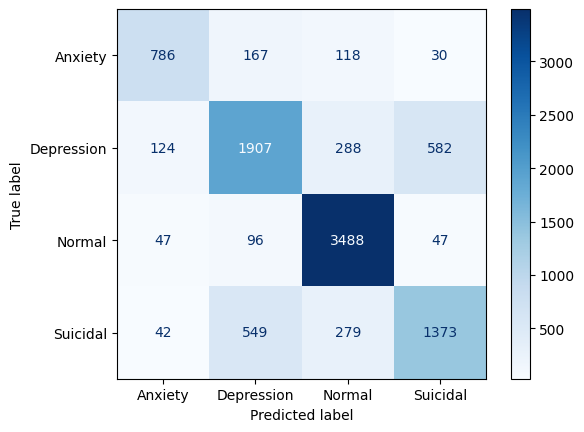

In [41]:
# Confusion Matrix for Logistic Regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=emotion_map)
disp.plot(cmap=plt.cm.Blues)
plt.show()

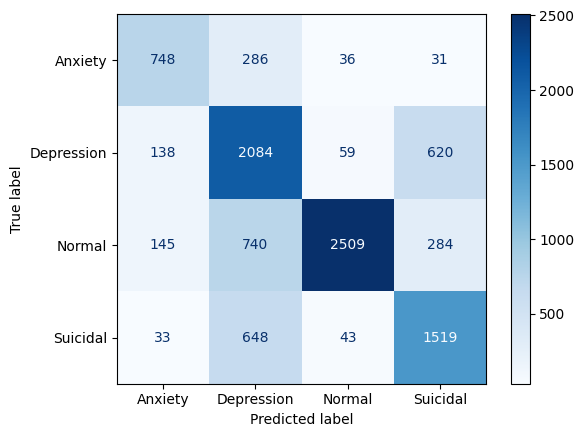

In [42]:
# Confusion Matrix for Naive Bayes
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=emotion_map)
disp.plot(cmap=plt.cm.Blues)
plt.show()

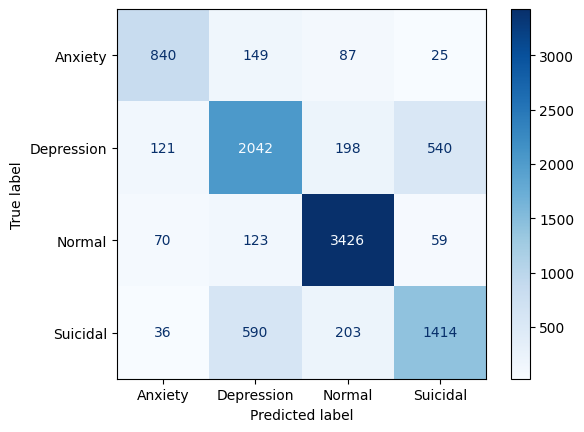

In [40]:
# Confusion Matrix for XGBoost
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=emotion_map)
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Receiver Operating Characteristic (ROC) and Area Under Curve Score

In [19]:
from sklearn.metrics import roc_auc_score

In [20]:
# ROC Curve's for Logistic Regression
# Anxiety 

# Depression

# Normal 

# Suicidal


# AUC Score's for Logistic Regression
# Anxiety 

# Depression

# Normal 

# Suicidal

In [21]:
# ROC Curve's for Naive Bayes
# Anxiety 

# Depression

# Normal 

# Suicidal


# AUC Score's for Naive Bayes
# Anxiety 

# Depression

# Normal 

# Suicidal

In [22]:
# ROC Curve's for XGBoost
# Anxiety 

# Depression

# Normal 

# Suicidal


# AUC Score's for XGBoost
# Anxiety 

# Depression

# Normal 

# Suicidal